# P03：训练 Dreamer 智能体

训练一个包含世界模型与潜在 Actor-Critic 策略的紧凑型 Dreamer 智能体。本项目为教程规模的演示：目标是展示 Dreamer 训练循环、权重文件的衔接方式以及指标诊断流程，而非求解高难度控制基准。本项目不依赖外部 gym 库，由 `SyntheticEnv` 生成 64×64 RGB 帧并附带简单奖励信号。

**前置条件**：若存在 P01 的 `vae_encoder.pt` 和 P02 的 `rssm.pt`，将自动加载；否则缺失部分退化为随机初始化，笔记本仍可运行，但只有在使用预训练权重文件的情况下，训练出的智能体才具有实际意义。本笔记本将完整智能体保存为 `dreamer.pt`，供 P05 使用。

此处出现嘈杂的奖励曲线是可以接受的；教程目标是构建一个可运行的世界模型加策略流水线，而非追求基准得分。

> Notebook 源文件: [p03_dreamer_agent.ipynb](https://github.com/datawhalechina/learn-world-model/blob/main/docs/zh/projects/p03_dreamer_agent.ipynb)

In [1]:
%%bash
# Install dependencies for a fresh environment.
if command -v rocm-smi >/dev/null || [ -d /opt/rocm ]; then
  pip install torch torchvision --index-url https://download.pytorch.org/whl/rocm7.2
  pip install matplotlib numpy
else
  pip install torch torchvision matplotlib numpy
fi


## 1. 初始化设置

定义共享环境、模型维度与训练计划。

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from pathlib import Path
try:
    from IPython import get_ipython
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# 让 Colab 和新环境优先使用支持中文的字体，避免标题和坐标轴显示成方框。
def _configure_cjk_font():
    preferred = [
        "Noto Sans CJK SC",
        "Noto Sans SC",
        "Source Han Sans SC",
        "Microsoft YaHei",
        "SimHei",
        "PingFang SC",
        "WenQuanYi Micro Hei",
    ]
    for family in preferred:
        try:
            font_manager.findfont(family, fallback_to_default=False)
            mpl.rcParams["font.family"] = "sans-serif"
            mpl.rcParams["font.sans-serif"] = [family] + [f for f in mpl.rcParams.get("font.sans-serif", []) if f != family]
            mpl.rcParams["axes.unicode_minus"] = False
            return family
        except Exception:
            pass

    font_path = Path.home() / ".cache" / "notebook-fonts" / "NotoSansCJKsc-Regular.otf"
    if not font_path.exists():
        try:
            import urllib.request
            font_path.parent.mkdir(parents=True, exist_ok=True)
            url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/SimplifiedChinese/NotoSansCJKsc-Regular.otf"
            urllib.request.urlretrieve(url, font_path)
        except Exception:
            font_path = None

    if font_path and font_path.exists():
        font_manager.fontManager.addfont(str(font_path))
        family = font_manager.FontProperties(fname=str(font_path)).get_name()
        mpl.rcParams["font.family"] = "sans-serif"
        mpl.rcParams["font.sans-serif"] = [family] + [f for f in preferred if f != family]
        mpl.rcParams["axes.unicode_minus"] = False
        return family

    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]
    mpl.rcParams["axes.unicode_minus"] = False
    return None

_CJK_FONT = _configure_cjk_font()
from collections import deque

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

try:
    import torch_xla.core.xla_model as xm
    _XLA_AVAILABLE = True
except Exception:
    xm = None
    _XLA_AVAILABLE = False


def _resolve_device():
    if _XLA_AVAILABLE:
        return xm.xla_device()
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


DEVICE = _resolve_device()
USE_TPU = DEVICE.type == 'xla'
USE_CUDA = DEVICE.type == 'cuda'
LOAD_DEVICE = torch.device('cpu') if USE_TPU else DEVICE


def optimizer_step(optimizer, scaler=None):
    if USE_TPU:
        xm.optimizer_step(optimizer)
    elif scaler is not None:
        scaler.step(optimizer)
        scaler.update()
    else:
        optimizer.step()

print(f'使用设备: {DEVICE}')
if USE_CUDA:
    print(f'CUDA 可用: {torch.cuda.is_available()}')

使用设备: cuda
CUDA 可用: True


### 1.1 超参数

保持参数规模较小，使完整训练循环能快速运行。

In [3]:
# 模型维度
IMG_SIZE    = 64
LATENT_DIM  = 32      # VAE / 随机潜在变量 z
HIDDEN_DIM  = 128     # RSSM 确定性隐状态 h
ACTION_DIM  = 2       # 二值动作空间
AC_HIDDEN   = 128     # Actor / Critic 隐层大小

# 训练计划
EPISODE_LEN   = 20    # 每个合成回合的步数
N_ITERATIONS  = 30    # 外层训练迭代次数
BATCH_SIZE    = 4     # 每次世界模型更新使用的轨迹数
IMAGINE_H     = 10    # 想象时域
LAMBDA_RETURN = 0.95  # TD(lambda)
GAMMA         = 0.99  # 折扣因子

# 学习率
LR_WM   = 3e-4
LR_AC   = 3e-4

# 权重文件路径（来自前序项目）
ENCODER_PATH = 'vae_encoder.pt'
RSSM_PATH    = 'rssm.pt'
SAVE_PATH    = 'dreamer.pt'

### 1.2 VAE 编码器

使用与 P01 相同的编码器结构。

In [4]:
class VAEEncoder(nn.Module):
    """将 64x64 RGB 帧编码为潜在均值和对数方差。"""
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),   # 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 8x8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),# 4x4
            nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x):
        """x: (B, 3, 64, 64) -> mu, logvar 各为 (B, latent_dim)"""
        h = self.conv(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def encode(self, x):
        mu, logvar = self.forward(x)
        std = (0.5 * logvar).exp()
        eps = torch.randn_like(std)
        return mu + eps * std, mu, logvar


class VAEDecoder(nn.Module):
    """解码器：潜在维度 -> 64x64 RGB 重建。"""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.fc = nn.Linear(latent_dim + hidden_dim, 256 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z, h):
        """z: (B, latent_dim), h: (B, hidden_dim) -> (B, 3, 64, 64)"""
        x = self.fc(torch.cat([z, h], dim=-1))
        x = x.view(x.size(0), 256, 4, 4)
        return self.deconv(x)

### 1.3 RSSM

复用 P02 中的潜在动态模型接口。

In [5]:
class RSSM(nn.Module):
    """兼容 P02 的 RSSM，提供适合 P03 的动作接口。"""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, action_dim=ACTION_DIM):
        super().__init__()
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        self.action_dim = action_dim

        # P02 权重文件期望标量动作特征。
        self.gru = nn.GRUCell(latent_dim + 1, hidden_dim)

        # 先验：p(z_t | h_t)
        self.prior_net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, 2 * latent_dim),
        )

        # 后验：q(z_t | h_t, e_t)
        self.post_net = nn.Sequential(
            nn.Linear(hidden_dim + latent_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, 2 * latent_dim),
        )
        self.recon = nn.Linear(latent_dim, latent_dim)

    def _action_feature(self, action):
        """将标量或 one-hot 动作转换为 P02 所需的标量动作输入。"""
        if action.dim() == 0:
            action = action.view(1, 1)
        elif action.dim() == 1:
            action = action.unsqueeze(-1)
        if action.shape[-1] > 1:
            # 二值动作：保留动作 1 的概率质量，使想象推演中的软动作
            # 在 Actor 训练时保持可微。
            action = action[..., 1:2]
        return action.float()

    def initial_state(self, batch_size):
        h = torch.zeros(batch_size, self.hidden_dim, device=DEVICE)
        z = torch.zeros(batch_size, self.latent_dim, device=DEVICE)
        return h, z

    def prior(self, h):
        out = self.prior_net(h)
        mu, logvar = out.chunk(2, dim=-1)
        std = F.softplus(logvar) + 0.1
        z = mu + std * torch.randn_like(std)
        return z, mu, std

    def posterior(self, h, enc_z):
        out = self.post_net(torch.cat([h, enc_z], dim=-1))
        mu, logvar = out.chunk(2, dim=-1)
        std = F.softplus(logvar) + 0.1
        z = mu + std * torch.randn_like(std)
        return z, mu, std

    def step(self, h, z, action_onehot):
        """推进确定性状态，返回新的 h。"""
        action_feat = self._action_feature(action_onehot)
        inp = torch.cat([z, action_feat], dim=-1)
        h_new = self.gru(inp, h)
        return h_new

### 1.4 Actor 与 Critic

两者均完全在潜在空间中训练。

In [6]:
class Actor(nn.Module):
    """将潜在状态 (h, z) 和轻量级观测特征映射为动作 logits。"""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, action_dim=ACTION_DIM, ac_hidden=AC_HIDDEN, obs_feat_dim=1):
        super().__init__()
        inp = hidden_dim + latent_dim + obs_feat_dim
        self.net = nn.Sequential(
            nn.Linear(inp, ac_hidden),
            nn.ELU(),
            nn.Linear(ac_hidden, ac_hidden),
            nn.ELU(),
            nn.Linear(ac_hidden, action_dim),
        )

    def forward(self, h, z, bar_pos=None):
        if bar_pos is None:
            bar_pos = torch.zeros(h.shape[0], 1, device=h.device)
        logits = self.net(torch.cat([h, z, bar_pos], dim=-1))
        return logits

    def sample(self, h, z, bar_pos=None):
        logits = self.forward(h, z, bar_pos=bar_pos)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        return action, dist


class Critic(nn.Module):
    """将潜在状态 (h, z) 映射为标量价值估计。"""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, ac_hidden=AC_HIDDEN):
        super().__init__()
        inp = hidden_dim + latent_dim
        self.net = nn.Sequential(
            nn.Linear(inp, ac_hidden),
            nn.ELU(),
            nn.Linear(ac_hidden, ac_hidden),
            nn.ELU(),
            nn.Linear(ac_hidden, 1),
        )

    def forward(self, h, z):
        return self.net(torch.cat([h, z], dim=-1)).squeeze(-1)


class RewardModel(nn.Module):
    """从潜在状态和动作预测即时奖励。"""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, action_dim=ACTION_DIM, ac_hidden=AC_HIDDEN):
        super().__init__()
        inp = hidden_dim + latent_dim + action_dim
        self.net = nn.Sequential(
            nn.Linear(inp, ac_hidden),
            nn.ELU(),
            nn.Linear(ac_hidden, ac_hidden),
            nn.ELU(),
            nn.Linear(ac_hidden, 1),
        )

    def forward(self, h, z, a):
        return self.net(torch.cat([h, z, a], dim=-1)).squeeze(-1)

### 1.5 合成环境

In [7]:
class SyntheticEnv:
    """带图像观测的简单合成控制环境。"""
    def __init__(self, episode_len=EPISODE_LEN, img_size=IMG_SIZE, seed=None):
        self.episode_len = episode_len
        self.img_size    = img_size
        self.rng         = np.random.default_rng(seed)
        self.pos         = 0.0
        self.step_count  = 0

    def _render(self):
        img = np.zeros((self.img_size, self.img_size, 3), dtype=np.float32)
        bar_x = int((self.pos + 1.0) / 2.0 * (self.img_size - 1))
        bar_x = np.clip(bar_x, 0, self.img_size - 1)
        img[:, max(0, bar_x - 2): bar_x + 3, 0] = 1.0  # 红色通道
        # 加入轻微背景噪声，使编码器面临非平凡任务
        img += self.rng.uniform(0, 0.05, img.shape).astype(np.float32)
        return np.clip(img, 0, 1)

    def reset(self):
        self.pos        = float(self.rng.uniform(-0.8, 0.8))
        self.step_count = 0
        return self._render()

    def step(self, action):
        """action: int（0 或 1）。返回 (obs, reward, done)。"""
        prev_abs = abs(self.pos)
        delta    = 0.1 if action == 1 else -0.1
        self.pos = float(np.clip(self.pos + delta, -1.0, 1.0))
        reward   = 1.0 if abs(self.pos) < prev_abs else -1.0
        self.step_count += 1
        done = self.step_count >= self.episode_len
        return self._render(), reward, done


# 快速完整性检查
env = SyntheticEnv(seed=0)
obs = env.reset()
print(f'观测形状: {obs.shape}, 数据类型: {obs.dtype}, 范围: [{obs.min():.2f}, {obs.max():.2f}]')
obs2, r, done = env.step(1)
print(f'执行动作后: 奖励={r}, 回合结束={done}')

观测形状: (64, 64, 3), 数据类型: float32, 范围: [0.00, 1.00]
执行动作后: 奖励=-1.0, 回合结束=False


### 1.6 加载或初始化模型

In [8]:
def obs_to_tensor(obs):
    """将 HWC numpy float32 转换为 (1, 3, H, W) 张量。"""
    t = torch.from_numpy(obs).permute(2, 0, 1).unsqueeze(0)
    return t.to(DEVICE)


encoder = VAEEncoder(latent_dim=LATENT_DIM).to(DEVICE)
decoder = VAEDecoder(latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
rssm    = RSSM(latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, action_dim=ACTION_DIM).to(DEVICE)
actor   = Actor(latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, action_dim=ACTION_DIM, ac_hidden=AC_HIDDEN).to(DEVICE)
critic  = Critic(latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, ac_hidden=AC_HIDDEN).to(DEVICE)
reward_model = RewardModel(latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, action_dim=ACTION_DIM, ac_hidden=AC_HIDDEN).to(DEVICE)

# 尝试从前序项目加载权重。
def _load_encoder_decoder_from_vae_checkpoint(path):
    ckpt = torch.load(path, map_location=DEVICE)
    state = ckpt.get('model_state_dict', ckpt) if isinstance(ckpt, dict) else ckpt

    if isinstance(ckpt, dict) and 'encoder' in ckpt:
        enc_state = {k.replace('fc_log_var', 'fc_logvar'): v for k, v in ckpt['encoder'].items()}
        encoder.load_state_dict(enc_state, strict=True)
        return '仅编码器（解码器在 P03 中有意重新初始化）'

    enc_state = {}
    dec_state = {}
    for key, value in state.items():
        if key.startswith('encoder.'):
            enc_key = key[len('encoder.'):].replace('fc_log_var', 'fc_logvar')
            enc_state[enc_key] = value
        elif key.startswith('decoder.'):
            dec_state[key[len('decoder.'):]] = value

    if not enc_state:
        raise KeyError(f'无法识别的 VAE 权重文件格式: {list(ckpt.keys())[:10] if isinstance(ckpt, dict) else type(ckpt)}')

    encoder.load_state_dict(enc_state, strict=True)
    return '仅编码器来自 model_state_dict（解码器在 P03 中有意重新初始化）'

vae_ckpt_candidates = [Path(ENCODER_PATH), Path('notebooks') / ENCODER_PATH]
vae_ckpt_path = next((p for p in vae_ckpt_candidates if p.exists()), None)
if vae_ckpt_path is not None:
    try:
        vae_ckpt_format = _load_encoder_decoder_from_vae_checkpoint(vae_ckpt_path)
        print(f'已从 {vae_ckpt_path} 加载编码器/解码器权重（{vae_ckpt_format}）')
    except Exception as e:
        print(f'无法从 {vae_ckpt_path} 加载编码器/解码器（{e}），使用随机初始化')
else:
    print('未找到 vae_encoder.pt，使用随机初始化编码器')

rssm_path = next((p for p in [Path(RSSM_PATH), Path('notebooks') / RSSM_PATH] if p.exists()), None)
if rssm_path is not None:
    try:
        state = torch.load(rssm_path, map_location=DEVICE)
        if isinstance(state, dict) and 'rssm_state_dict' in state:
            sd = state['rssm_state_dict']
            rssm.load_state_dict(sd, strict=True)
            print(
                f"已从 {rssm_path} 加载 RSSM 权重 "
                f"(hidden_dim={state.get('hidden_dim', HIDDEN_DIM)}, latent_dim={state.get('latent_dim', LATENT_DIM)}, action_dim={state.get('action_dim', 1)})"
            )
        elif isinstance(state, dict) and 'rssm' in state:
            rssm.load_state_dict(state['rssm'], strict=False)
            print(f'已从 {rssm_path} 加载 RSSM 权重（旧版 rssm 键）')
        else:
            rssm.load_state_dict(state, strict=False)
            print(f'已从 {rssm_path} 加载 RSSM 权重（原始 state_dict）')
    except Exception as e:
        print(f'无法加载 RSSM（{e}），使用随机初始化')
else:
    print('未找到 rssm.pt，使用随机初始化 RSSM')

print('\n各模型参数量:')
for name, m in [('encoder', encoder), ('decoder', decoder), ('rssm', rssm), ('actor', actor), ('critic', critic), ('reward_model', reward_model)]:
    n = sum(p.numel() for p in m.parameters())
    print(f'  {name}: {n:,}')

已从 vae_encoder.pt 加载编码器/解码器权重（仅编码器（解码器在 P03 中有意重新初始化））
已从 rssm.pt 加载 RSSM 权重 (hidden_dim=128, latent_dim=32, action_dim=1)

各模型参数量:
  encoder: 952,352
  decoder: 1,349,347
  rssm: 117,280
  actor: 37,506
  critic: 37,249
  reward_model: 37,505


### 1.7 回放缓冲区与优化器

In [9]:
# 回放缓冲区存储轨迹字典。
replay_buffer = deque(maxlen=200)

# 世界模型优化器涵盖编码器、解码器和 RSSM
wm_params = list(encoder.parameters()) + list(decoder.parameters()) + list(rssm.parameters()) + list(reward_model.parameters())
opt_wm    = optim.Adam(wm_params, lr=LR_WM)

opt_actor  = optim.Adam(actor.parameters(),  lr=LR_AC)
opt_critic = optim.Adam(critic.parameters(), lr=LR_AC)

print('优化器已初始化。')

优化器已初始化。


## 2. 世界模型更新

In [10]:
def action_to_onehot(action_int, action_dim=ACTION_DIM):
    """标量整数 -> (1, action_dim) one-hot 张量。"""
    oh = torch.zeros(1, action_dim, device=DEVICE)
    oh[0, action_int] = 1.0
    return oh


def world_model_update(batch):
    """执行一次世界模型 ELBO 更新。"""
    encoder.train()
    decoder.train()
    rssm.train()
    opt_wm.zero_grad()

    total_recon = 0.0
    total_kl    = 0.0
    total_reward = 0.0
    count       = 0

    for traj in batch:
        obs_list  = traj['obs']     # T+1 个 numpy 数组列表 (H,W,3)
        act_list  = traj['actions'] # T 个整数列表
        T         = len(act_list)

        h, z = rssm.initial_state(1)

        for t in range(T):
            obs_t    = obs_to_tensor(obs_list[t])           # (1,3,64,64)
            obs_next = obs_to_tensor(obs_list[t + 1])
            a_oh     = action_to_onehot(act_list[t])        # (1, action_dim)

            # 编码当前观测
            enc_z, enc_mu, enc_logvar = encoder.encode(obs_t)

            # 由编码器嵌入得到后验
            z_post, post_mu, post_std = rssm.posterior(h, enc_z)

            # 由确定性状态得到先验
            _, prior_mu, prior_std = rssm.prior(h)

            # 重建下一帧观测
            h_next = rssm.step(h, z_post.detach(), a_oh)
            recon  = decoder(z_post, h_next)

            # 从潜在状态预测实际转移奖励
            reward_target = torch.tensor([traj['rewards'][t]], device=DEVICE, dtype=torch.float32)
            reward_pred   = reward_model(h, z_post, a_oh)

            # 重建损失（每像素 MSE，在空间维度上取均值）
            recon_loss = F.mse_loss(recon, obs_next, reduction='mean')

            # KL 散度：后验 || 先验（封闭形式，均为高斯分布）
            kl = 0.5 * (
                (post_std / prior_std).pow(2)
                + ((post_mu - prior_mu) / prior_std).pow(2)
                - 1
                + 2 * prior_std.log()
                - 2 * post_std.log()
            ).sum(dim=-1).mean()

            reward_loss = F.mse_loss(reward_pred, reward_target)

            total_recon = total_recon + recon_loss
            total_kl    = total_kl    + kl
            total_reward = total_reward + reward_loss
            count       += 1

            # 推进状态（detach 以避免跨步的时间反向传播）
            h = h_next.detach()
            z = z_post.detach()

    loss = (total_recon + total_kl + total_reward) / max(count, 1)
    loss.backward()
    nn.utils.clip_grad_norm_(wm_params, 100.0)
    opt_wm.step()

    return (total_recon / count).item(), (total_kl / count).item(), (total_reward / count).item()


print('world_model_update 已定义。')

world_model_update 已定义。


## 3. 行为学习（想象推演）

In [11]:
def lambda_returns(rewards, values, gamma=GAMMA, lam=LAMBDA_RETURN):
    """计算想象推演的 lambda 回报目标。"""
    H = rewards.shape[0]
    G = torch.zeros(H, device=DEVICE)
    G_next = values[H]
    for t in reversed(range(H)):
        td = rewards[t] + gamma * values[t + 1]
        G_next = (1 - lam) * td + lam * gamma * G_next
        G[t] = G_next
    return G


def set_requires_grad(module, flag):
    for p in module.parameters():
        p.requires_grad_(flag)


def imagined_rollout(start_h, start_z, horizon=IMAGINE_H, differentiable=False, tau=0.8):
    """在想象空间中展开潜在轨迹。"""
    h, z = start_h, start_z
    h_seq, z_seq, r_seq, ent_seq = [], [], [], []

    for _ in range(horizon):
        logits = actor(h, z)
        dist = torch.distributions.Categorical(logits=logits)
        ent_seq.append(dist.entropy().mean())

        if differentiable:
            a_oh = F.gumbel_softmax(logits, tau=tau, hard=True, dim=-1)
            r_hat = reward_model(h, z, a_oh)
            h_next = rssm.step(h, z, a_oh)
            prior_out = rssm.prior_net(h_next)
            prior_mu, _ = prior_out.chunk(2, dim=-1)
            z_next = prior_mu
        else:
            a = dist.sample()
            a_oh = F.one_hot(a, num_classes=ACTION_DIM).float()
            with torch.no_grad():
                r_hat = reward_model(h, z, a_oh)
                h_next = rssm.step(h, z, a_oh)
                prior_out = rssm.prior_net(h_next)
                prior_mu, _ = prior_out.chunk(2, dim=-1)
                z_next = prior_mu

        h_seq.append(h)
        z_seq.append(z)
        r_seq.append(r_hat)
        h, z = h_next, z_next

    h_all = torch.stack(h_seq, dim=0)
    z_all = torch.stack(z_seq, dim=0)
    r_all = torch.stack(r_seq, dim=0).mean(dim=-1)
    return h_all, z_all, r_all, ent_seq


def behavior_update(start_h, start_z, horizon=IMAGINE_H):
    """在想象回报上训练 Critic。"""
    critic.train()
    reward_model.eval()
    rssm.eval()

    with torch.no_grad():
        h_all, z_all, r_all, ent_seq = imagined_rollout(start_h.detach(), start_z.detach(), horizon=horizon, differentiable=False)

    v_all = torch.zeros(horizon + 1, device=DEVICE)
    for t in range(horizon):
        v_all[t] = critic(h_all[t], z_all[t]).mean().detach()
    v_all[horizon] = critic(h_all[-1], z_all[-1]).mean().detach()
    G = lambda_returns(r_all, v_all)

    opt_critic.zero_grad()
    v_pred = torch.stack([critic(h_all[t], z_all[t]).mean() for t in range(horizon)])
    critic_loss = F.mse_loss(v_pred, G.detach())
    critic_loss.backward()
    nn.utils.clip_grad_norm_(critic.parameters(), 100.0)
    opt_critic.step()

    return torch.stack(ent_seq).mean().item()


print('behavior_update 已定义。')


behavior_update 已定义。


## 4. 训练循环

In [12]:
def collect_episode(env_seed=None, deterministic=False, epsilon=0.05):
    """使用当前 Actor 收集一个回合的数据。"""
    env = SyntheticEnv(seed=env_seed)
    obs = env.reset()
    traj = {'obs': [obs], 'actions': [], 'rewards': []}

    h, z = rssm.initial_state(1)
    actor.eval()
    encoder.eval()
    rssm.eval()

    total_reward = 0.0
    done = False

    with torch.no_grad():
        while not done:
            obs_t = obs_to_tensor(obs)
            enc_z, _, _ = encoder.encode(obs_t)
            z_post, _, _ = rssm.posterior(h, enc_z)
            bar_pos = obs_to_bar_pos(obs)
            logits = actor(h, z_post, bar_pos=bar_pos)
            dist   = torch.distributions.Categorical(logits=logits)
            if deterministic:
                a_int = int(torch.argmax(logits, dim=-1).item())
            else:
                if random.random() < epsilon:
                    a_int = random.randint(0, ACTION_DIM - 1)
                else:
                    a_int = int(dist.sample().item())

            obs_next, reward, done = env.step(a_int)

            a_oh = action_to_onehot(a_int)
            h = rssm.step(h, z_post, a_oh)
            z = z_post

            traj['obs'].append(obs_next)
            traj['actions'].append(a_int)
            traj['rewards'].append(reward)
            obs = obs_next
            total_reward += reward

    return traj, total_reward


def obs_to_bar_pos(obs):
    """从红色通道估计滑块位置，返回归一化标量。"""
    red_profile = obs[:, :, 0].mean(axis=0)
    bar_x = int(np.argmax(red_profile))
    denom = max(obs.shape[1] - 1, 1)
    bar_pos = (2.0 * bar_x / denom) - 1.0
    return torch.tensor([[bar_pos]], device=DEVICE, dtype=torch.float32)


def get_rssm_states_from_traj(traj):
    """在轨迹上重新运行 RSSM，获取后验 (h, z) 对，用于想象推演。"""
    encoder.eval()
    rssm.eval()
    h, z = rssm.initial_state(1)
    h_list, z_list = [], []
    with torch.no_grad():
        for t, a_int in enumerate(traj['actions']):
            obs_t = obs_to_tensor(traj['obs'][t])
            enc_z, _, _ = encoder.encode(obs_t)
            z_post, _, _ = rssm.posterior(h, enc_z)
            h_list.append(h)
            z_list.append(z_post)
            a_oh = action_to_onehot(a_int)
            h = rssm.step(h, z_post, a_oh)
    return torch.cat(h_list, dim=0), torch.cat(z_list, dim=0)  # (T, dim)


def expert_action_from_obs(obs):
    """为合成滑块任务返回向中心移动的专家动作。"""
    red_profile = obs[:, :, 0].mean(axis=0)
    bar_x = int(np.argmax(red_profile))
    center = obs.shape[1] // 2
    return 1 if bar_x < center else 0


def supervised_policy_update(batch):
    """训练 Actor 模仿回放轨迹上向中心移动的专家策略。"""
    actor.train()
    losses = []
    for traj in batch:
        h_states, z_states = get_rssm_states_from_traj(traj)
        targets = torch.tensor([expert_action_from_obs(obs) for obs in traj['obs'][:-1]], device=DEVICE, dtype=torch.long)
        bar_pos = torch.cat([obs_to_bar_pos(obs) for obs in traj['obs'][:-1]], dim=0)
        logits = actor(h_states, z_states, bar_pos=bar_pos)
        losses.append(F.cross_entropy(logits, targets))

    loss = torch.stack(losses).mean()
    opt_actor.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(actor.parameters(), 100.0)
    opt_actor.step()
    return loss.item()


print('数据收集工具已定义，开始训练...')


数据收集工具已定义，开始训练...


轨迹采样已经准备好，先把指标历史记录搭起来，方便训练循环持续写入结果。

In [13]:
# 指标历史记录。
ep_rewards      = []
recon_losses    = []
kl_losses       = []
reward_losses   = []
policy_losses   = []
actor_entropies = []

for iteration in range(N_ITERATIONS):
    # --- 收集一个回合 ---
    traj, ep_reward = collect_episode(env_seed=iteration, deterministic=False, epsilon=0.10)
    replay_buffer.append(traj)
    ep_rewards.append(ep_reward)

    # --- 世界模型更新 ---
    buf_list = list(replay_buffer)
    n_sample = min(BATCH_SIZE, len(buf_list))
    batch    = random.sample(buf_list, n_sample)
    recon_l, kl_l, reward_l = world_model_update(batch)
    recon_losses.append(recon_l)
    kl_losses.append(kl_l)
    reward_losses.append(reward_l)

    # --- Critic 更新（想象推演）---
    h_states, z_states = get_rssm_states_from_traj(traj)
    entropy = behavior_update(h_states, z_states, horizon=IMAGINE_H)
    actor_entropies.append(entropy)

    # --- 从回放中使用简单专家策略更新 Actor ---
    policy_l = supervised_policy_update(batch)
    policy_losses.append(policy_l)

    if (iteration + 1) % 10 == 0:
        print(
            f'迭代 {iteration+1:3d} | '
            f'回合奖励={ep_reward:+.1f} | '
            f'重建={recon_l:.4f} | '
            f'KL={kl_l:.4f} | '
            f'奖励={reward_l:.4f} | '
            f'策略={policy_l:.4f} | '
            f'Actor熵={entropy:.4f}'
        )

print('\n训练完成。')


迭代  10 | 回合奖励=+0.0 | 重建=0.1985 | KL=3.8400 | 奖励=1.0036 | 策略=0.6590 | Actor熵=0.6911
迭代  20 | 回合奖励=+0.0 | 重建=0.0894 | KL=1.4195 | 奖励=0.9882 | 策略=0.6009 | Actor熵=0.6506
迭代  30 | 回合奖励=+4.0 | 重建=0.0350 | KL=0.5571 | 奖励=0.9814 | 策略=0.6921 | Actor熵=0.6798

训练完成。


指标历史结构就绪后，接着把它们画成学习曲线，观察智能体是否在持续变好。

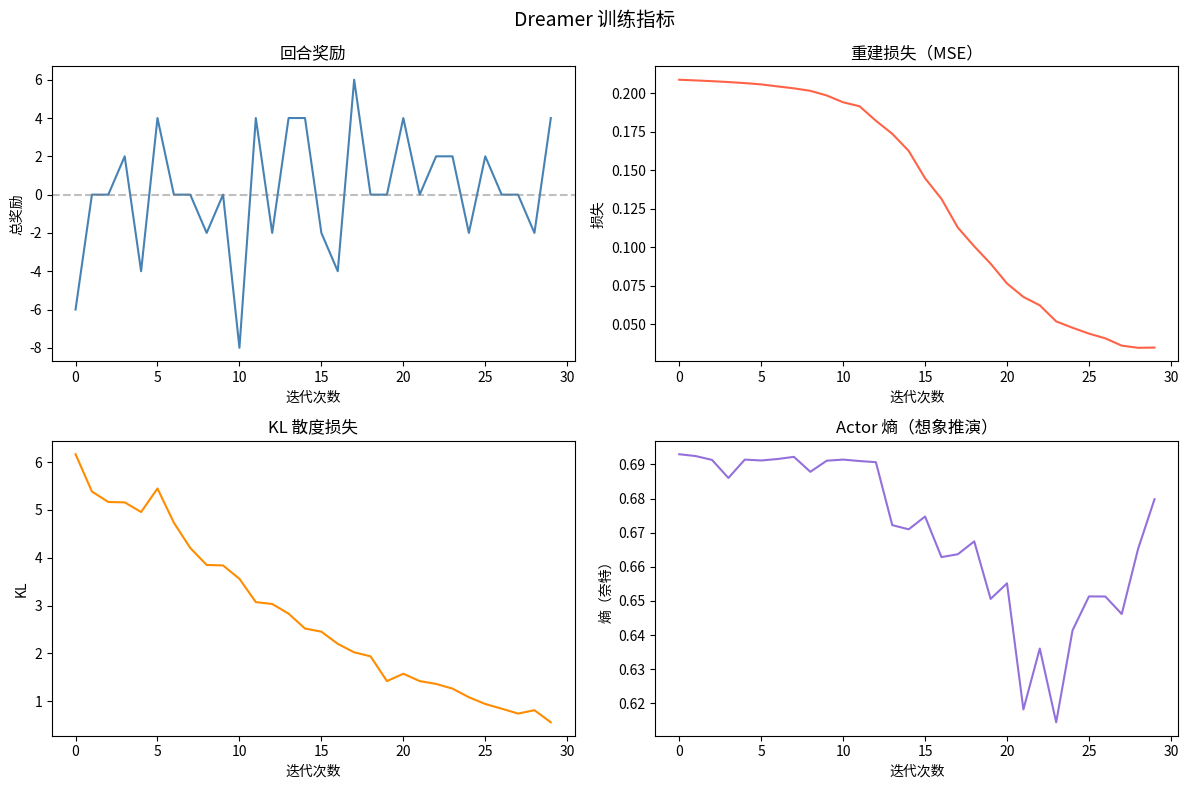

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Dreamer 训练指标', fontsize=14)

axes[0, 0].plot(ep_rewards, color='steelblue')
axes[0, 0].set_title('回合奖励')
axes[0, 0].set_xlabel('迭代次数')
axes[0, 0].set_ylabel('总奖励')
axes[0, 0].axhline(0, color='gray', linestyle='--', alpha=0.5)

axes[0, 1].plot(recon_losses, color='tomato')
axes[0, 1].set_title('重建损失（MSE）')
axes[0, 1].set_xlabel('迭代次数')
axes[0, 1].set_ylabel('损失')

axes[1, 0].plot(kl_losses, color='darkorange')
axes[1, 0].set_title('KL 散度损失')
axes[1, 0].set_xlabel('迭代次数')
axes[1, 0].set_ylabel('KL')

axes[1, 1].plot(actor_entropies, color='mediumpurple')
axes[1, 1].set_title('Actor 熵（想象推演）')
axes[1, 1].set_xlabel('迭代次数')
axes[1, 1].set_ylabel('熵（奈特）')

plt.tight_layout()
plt.show()

## 5. 自评估指标

In [15]:
def imagined_rollout_rewards(start_h, start_z, horizon=10, deterministic=True):
    """使用 Actor 和奖励模型在想象空间中前向推演。"""
    actor.eval()
    reward_model.eval()
    rssm.eval()
    h, z = start_h.clone(), start_z.clone()
    im_rewards = []
    im_entropies = []

    with torch.no_grad():
        for _ in range(horizon):
            logits = actor(h, z)
            dist   = torch.distributions.Categorical(logits=logits)
            im_entropies.append(dist.entropy().mean().item())
            if deterministic:
                a = torch.argmax(logits, dim=-1)
            else:
                a = dist.sample()
            a_oh   = F.one_hot(a, num_classes=ACTION_DIM).float()
            r_hat  = reward_model(h, z, a_oh).mean().item()
            im_rewards.append(r_hat)
            h = rssm.step(h, z, a_oh)
            prior_out = rssm.prior_net(h)
            z, _ = prior_out.chunk(2, dim=-1)

    return im_rewards, im_entropies


N_EVAL     = 10
EVAL_H     = EPISODE_LEN

real_reward_sums  = []
imag_reward_sums  = []
imag_entropies_ev = []

encoder.eval()
rssm.eval()
actor.eval()
reward_model.eval()

for ep_i in range(N_EVAL):
    # 收集真实回合
    traj, ep_r = collect_episode(env_seed=1000 + ep_i, deterministic=True)
    real_reward_sums.append(sum(traj['rewards']))

    # 以第一步的 RSSM 状态作为想象推演的起点
    h0, z0 = get_rssm_states_from_traj(traj)
    seed_h  = h0[0:1]   # 单步
    seed_z  = z0[0:1]

    # 想象奖励与熵
    im_r, ents = imagined_rollout_rewards(seed_h, seed_z, horizon=EVAL_H, deterministic=True)
    imag_reward_sums.append(sum(im_r))
    imag_entropies_ev.append(float(np.mean(ents)))

print(f'在 {N_EVAL} 个回合上的评估完成。')
print(f'  真实奖励均值（完整回合）:          {np.mean(real_reward_sums):.3f}')
print(f'  预测奖励均值（想象推演）:           {np.mean(imag_reward_sums):.3f}')
print(f'  想象轨迹熵均值:                    {np.mean(imag_entropies_ev):.4f}')


在 10 个回合上的评估完成。
  真实奖励均值（完整回合）:          -3.000
  预测奖励均值（想象推演）:           1.631
  想象轨迹熵均值:                    0.6792


想象推演函数已经定义好，下面比较 imagined reward 和真实回报，检查规划是否真的对齐环境信号。

In [16]:
# 计算想象奖励与真实奖励之和的 Pearson 相关系数
r_real = np.array(real_reward_sums)
r_imag = np.array(imag_reward_sums)

if r_real.std() > 1e-8 and r_imag.std() > 1e-8:
    rho = np.corrcoef(r_real, r_imag)[0, 1]
else:
    rho = 0.0

print(f'奖励相关性 rho（预测值与真实值，{EVAL_H} 步）: {rho:.4f}')
print(f'想象轨迹熵均值:                              {np.mean(imag_entropies_ev):.4f}')


奖励相关性 rho（预测值与真实值，20 步）: 0.3281
想象轨迹熵均值:                              0.6792


相关性摘要完成后，再把各类诊断图并排放出来，做一次快速的 sanity check。

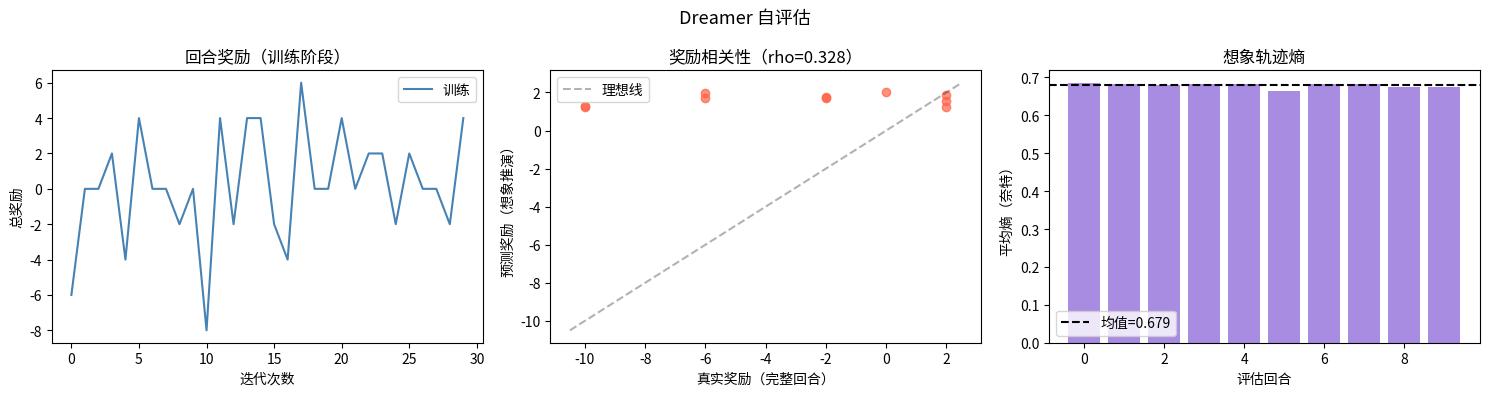

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Dreamer 自评估', fontsize=13)

# 训练过程中的回合奖励
axes[0].plot(ep_rewards, color='steelblue', label='训练')
axes[0].set_title('回合奖励（训练阶段）')
axes[0].set_xlabel('迭代次数')
axes[0].set_ylabel('总奖励')
axes[0].legend()

# 奖励相关性散点图
axes[1].scatter(r_real, r_imag, color='tomato', alpha=0.7)
axes[1].set_title(f'奖励相关性（rho={rho:.3f}）')
axes[1].set_xlabel(f'真实奖励（完整回合）')
axes[1].set_ylabel('预测奖励（想象推演）')
lims = [min(r_real.min(), r_imag.min()) - 0.5, max(r_real.max(), r_imag.max()) + 0.5]
axes[1].plot(lims, lims, 'k--', alpha=0.3, label='理想线')
axes[1].legend()

# 各评估回合的想象轨迹熵
axes[2].bar(range(N_EVAL), imag_entropies_ev, color='mediumpurple', alpha=0.8)
axes[2].set_title('想象轨迹熵')
axes[2].set_xlabel('评估回合')
axes[2].set_ylabel('平均熵（奈特）')
axes[2].axhline(np.mean(imag_entropies_ev), color='black', linestyle='--', label=f'均值={np.mean(imag_entropies_ev):.3f}')
axes[2].legend()

plt.tight_layout()
plt.show()


## 6. 保存权重文件

In [18]:
checkpoint = {
    'encoder': encoder.state_dict(),
    'decoder': decoder.state_dict(),
    'rssm':    rssm.state_dict(),
    'actor':   actor.state_dict(),
    'critic':  critic.state_dict(),
    'reward_model': reward_model.state_dict(),
    'hyperparams': {
        'latent_dim':  LATENT_DIM,
        'hidden_dim':  HIDDEN_DIM,
        'action_dim':  ACTION_DIM,
        'ac_hidden':   AC_HIDDEN,
    },
    'metrics': {
        'ep_rewards':      ep_rewards,
        'recon_losses':    recon_losses,
        'kl_losses':       kl_losses,
        'reward_losses':   reward_losses,
        'policy_losses':   policy_losses,
        'actor_entropies': actor_entropies,
        'reward_corr_rho': float(rho),
        'mean_imag_entropy': float(np.mean(imag_entropies_ev)),
        'mean_eval_reward': float(np.mean(real_reward_sums)),
        'mean_pred_reward': float(np.mean(imag_reward_sums)),
    },
}
torch.save(checkpoint, SAVE_PATH)
print(f'权重文件已保存至 {SAVE_PATH}')

# 训练摘要
print('\n--- 训练摘要 ---')
print(f'  末尾 10 轮探索回合奖励均值:      {np.mean(ep_rewards[-10:]):.2f}')
print(f'  最终重建损失:                    {recon_losses[-1]:.4f}')
print(f'  最终 KL 损失:                    {kl_losses[-1]:.4f}')
print(f'  最终奖励损失:                    {reward_losses[-1]:.4f}')
print(f'  最终策略损失:                    {policy_losses[-1]:.4f}')
print(f'  最终 Actor 熵:                   {actor_entropies[-1]:.4f}')
print(f'  奖励相关性 rho:                  {rho:.4f}')
print(f'  想象轨迹熵均值:                  {np.mean(imag_entropies_ev):.4f}')
print(f'  评估真实奖励均值:                {np.mean(real_reward_sums):.2f}')


权重文件已保存至 dreamer.pt

--- 训练摘要 ---
  末尾 10 轮探索回合奖励均值:      1.00
  最终重建损失:                    0.0350
  最终 KL 损失:                    0.5571
  最终奖励损失:                    0.9814
  最终策略损失:                    0.6921
  最终 Actor 熵:                   0.6798
  奖励相关性 rho:                  0.3281
  想象轨迹熵均值:                  0.6792
  评估真实奖励均值:                -3.00
